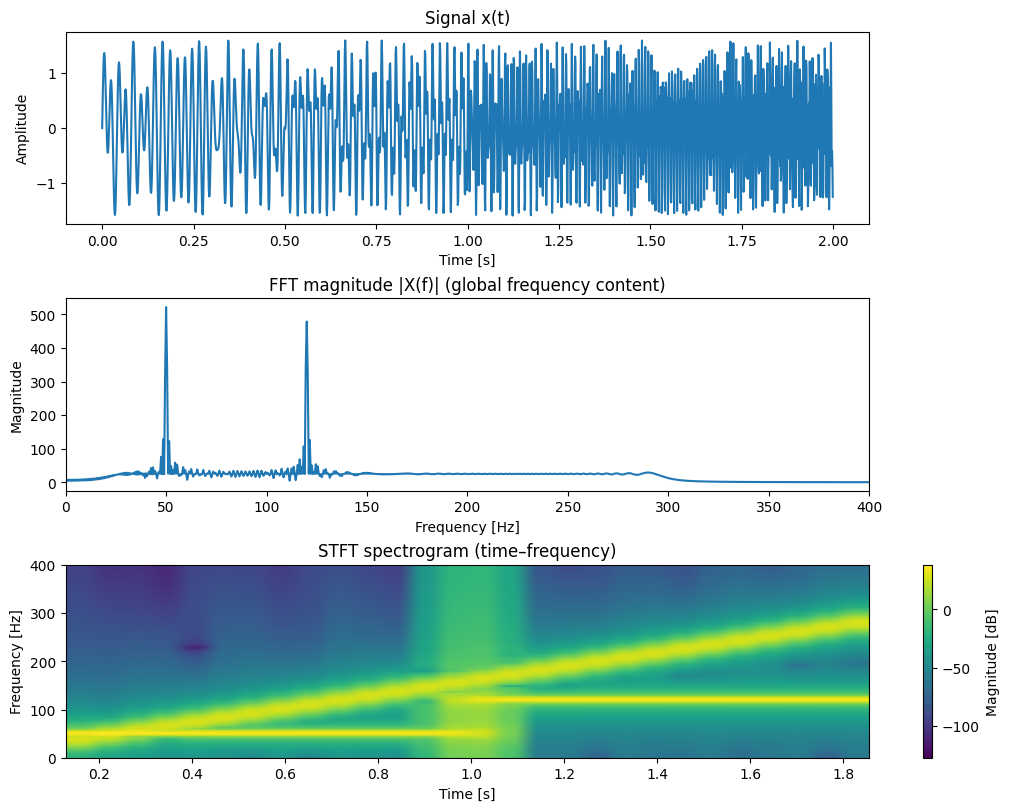

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Make a signal (time-domain)
# -----------------------------
fs = 1000  # Hz
T = 2.0    # seconds
t = np.arange(int(fs*T)) / fs

# A signal that changes over time:
# - 0-1s: 50 Hz sine
# - 1-2s: 120 Hz sine
# plus a chirp-like component to make time-frequency interesting
x = np.zeros_like(t)
x[t < 1.0] = np.sin(2*np.pi*50*t[t < 1.0])
x[t >= 1.0] = np.sin(2*np.pi*120*t[t >= 1.0])

# Add a "chirp" using phase = 2π * (f0 t + 0.5 k t^2)
f0, f1 = 20, 300
k = (f1 - f0) / T
chirp = np.sin(2*np.pi*(f0*t + 0.5*k*t**2))
x = x + 0.6*chirp

# -----------------------------
# 2) Fourier transform (FFT)
# -----------------------------
X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(len(x), d=1/fs)
mag = np.abs(X)

# -----------------------------
# 3) Time-frequency (STFT)
#    NumPy implementation
# -----------------------------
win_len = 256
hop = 64
window = np.hanning(win_len)

# Frame the signal: shape (n_frames, win_len)
n_frames = 1 + (len(x) - win_len) // hop
frames = np.stack([x[i*hop : i*hop + win_len] for i in range(n_frames)], axis=0)
frames_win = frames * window[None, :]

# FFT each frame -> spectrogram
S = np.fft.rfft(frames_win, axis=1)                 # (n_frames, n_freq_bins)
S_mag = np.abs(S).T                                 # (n_freq_bins, n_frames)
S_db = 20*np.log10(S_mag + 1e-12)                   # dB scale (avoid log(0))

times = (np.arange(n_frames)*hop + win_len/2) / fs  # center time of each frame
freqs_stft = np.fft.rfftfreq(win_len, d=1/fs)

# -----------------------------
# 4) Plot
# -----------------------------
fig, axs = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)

axs[0].plot(t, x)
axs[0].set_title("Signal x(t)")
axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel("Amplitude")

axs[1].plot(freqs, mag)
axs[1].set_title("FFT magnitude |X(f)| (global frequency content)")
axs[1].set_xlabel("Frequency [Hz]")
axs[1].set_ylabel("Magnitude")
axs[1].set_xlim(0, 400)

im = axs[2].imshow(
    S_db,
    origin="lower",
    aspect="auto",
    extent=[times[0], times[-1], freqs_stft[0], freqs_stft[-1]]
)
axs[2].set_title("STFT spectrogram (time–frequency)")
axs[2].set_xlabel("Time [s]")
axs[2].set_ylabel("Frequency [Hz]")
axs[2].set_ylim(0, 400)
plt.colorbar(im, ax=axs[2], label="Magnitude [dB]")

plt.show()


In [2]:
import numpy as np
from scipy.io import loadmat
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import ttest_rel
from sklearn.covariance import LedoitWolf
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from scipy import stats
import skfda
from skfda.representation.grid import FDataGrid

import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

/home/hpc/dsaa/dsaa110h/projects/neuroscience


In [3]:
# Read .mat files
data_ts = loadmat('data_processed/lsd/time_series_data.mat')
data_names = loadmat('data_processed/lsd/condition_names.mat')
parts = ['Thalamus','Visual_Cortex','Posterior_Cingulate_Cortex', 'Temporal_Gyrus']

data = {str(data_names['conditionNames'][0,i][0]): np.array([data_ts['pyDict'][0,i][part][0,0] for part in parts]).transpose(1,0,2) for i in range(3)}
print(data.keys())
n_subs, n_rois, n_time = data['LSD'].shape  # (number of subjects, number of ROIs, number of time points)

dict_keys(['Placebo', 'LSD', 'LSD+Ketanserin'])


In [6]:
x = data['Placebo'][0,0,:]

In [18]:
win_len = 26
hop = 13
window = np.hanning(win_len)

# Frame the signal: shape (n_frames, win_len)
n_frames = 1 + (len(x) - win_len) // hop
frames = np.stack([x[i*hop : i*hop + win_len] for i in range(n_frames)], axis=0)
frames_win = frames * window[None, :]

# FFT each frame -> spectrogram
S = np.fft.rfft(frames_win, axis=1)                 # (n_frames, n_freq_bins)
S_mag = np.abs(S).T                                 # (n_freq_bins, n_frames)
S_db = 20*np.log10(S_mag + 1e-12)                   # dB scale (avoid log(0))

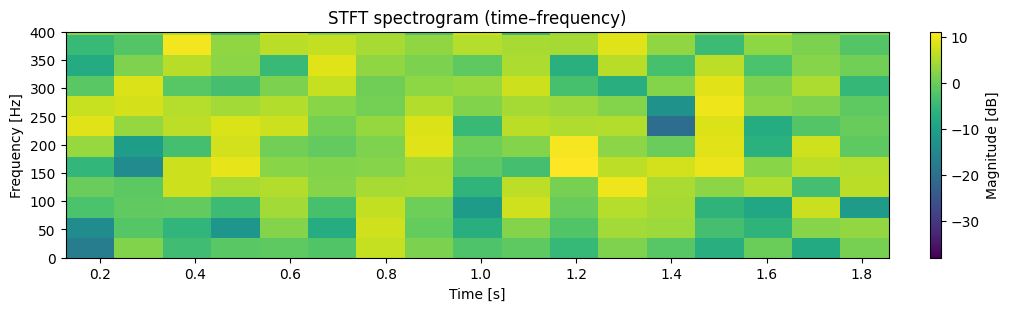

In [19]:
fig, axs = plt.subplots(1, 1, figsize=(10, 3), constrained_layout=True)

im = axs.imshow(
    S_db,
    origin="lower",
    aspect="auto",
    extent=[times[0], times[-1], freqs_stft[0], freqs_stft[-1]]
)
axs.set_xlabel("Time [s]")
axs.set_title("STFT spectrogram (time–frequency)")
axs.set_ylabel("Frequency [Hz]")
axs.set_ylim(0, 400)
plt.colorbar(im, ax=axs, label="Magnitude [dB]")

plt.show()